
<div style="border:solid green 2px; padding: 20px">

👋 **Hello! I'm Dot, your AI reviewer.**

I've completed the first pass of your code review. Below, you'll find my comments and suggestions for improvement.

**What should you do next?**

1. **Review:** check my comments in the notebook below.
2. **Decide:**
* **Agree with the feedback?** Great! Update your code accordingly.
* **Disagree or think it's a mistake?** No problem! You can keep your code exactly as it is.


3. **Resubmit:** Send your project back. **Your next iteration will be reviewed by a human expert**, whether you made changes or not.

-------------------------------------------------------------------------------------------------------------
Please find my comments below—**I kindly ask that you do not move, modify, or delete them**.

You can find my comments highlighted in green, yellow, or red boxes like this:

<div class="alert alert-block alert-success">
<b>Reviewer's comment, Iteration X</b> <a class="tocSkip"></a>

Success. Everything is done succesfully.
</div>

<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration X</b> <a class="tocSkip"></a>

Remarks. Some recommendations.
</div>

<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration X</b> <a class="tocSkip"></a>

Needs fixing. The block requires some corrections.
</div>



<div style="border:solid Purple 2px; padding: 20px">

**Hello Yaser,**

My name is **John Dickson** (https://hub.tripleten.com/u/13efa053) and today I'll be reviewing your project!

V2

<div style="border: 2px solid Green; padding: 5px; margin: 5px">
 
**What Was Great:**

- You have well with the data preperation
- Merging tables is done well
- Revenue calculations work. 
  
</div>
<div style="border: 2px solid red; padding: 5px; margin: 5px">

**What could be improved:**

- Make sure that things are kept in the correct section.
- Running code to drop missing values when it has been identified there are none indicates not fully understanding the data (or AI use)
- Make sure the graphs that are ment to be compared have a consistent axis, significant differences in axis make comparison difficult
- The second hypothesis test does not compare the required 2 groups. 

</div>

<div style="border:solid green 2px; padding: 20px">
<b>Reviewer's comment v3:</b>

    
<b>Overall Feedback</b>
    
Hello Yaser,

My name is **Gerardo Flores** and you can find me on the HUB as https://hub.tripleten.com/u/1949959f
    
You’ve submitted another project—great work! Your commitment to pushing through the challenges of this program is admirable.

After reviewing your submission, it is approved.
    
   
You can find my more detailed notes within your project notebook in the `Reviewer's comment v3:` section.


If you find yourself uncertain or in need of further insights, never hesitate to consult with your tutor or ask your questions here. We are here to guide and assist you.



# Which one is a better plan?

You work as an analyst for the telecom operator Megaline. The company offers its clients two prepaid plans, Surf and Ultimate. The commercial department wants to know which of the plans brings in more revenue in order to adjust the advertising budget.

You are going to carry out a preliminary analysis of the plans based on a relatively small client selection. You'll have the data on 500 Megaline clients: who the clients are, where they're from, which plan they use, and the number of calls they made and text messages they sent in 2018. Your job is to analyze the clients' behavior and determine which prepaid plan brings in more revenue.



[We've provided you with some commentary to guide your thinking as you complete this project. However, make sure to remove all the bracketed comments before submitting your project.]

[Before you dive into analyzing your data, explain for yourself the purpose of the project and actions you plan to take.]

[Please bear in mind that studying, amending, and analyzing data is an iterative process. It is normal to return to previous steps and correct/expand them to allow for further steps.]

<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

The bracketed template guidance is still present. Consider replacing it with a short statement of the project goal and your planned analysis steps, and remove the bracketed text before submitting.

</div>


## Initialization

In [1]:
# Loading all the libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats




## Load data

In [2]:
# Load the data files into different DataFrames
# Load the data files into different DataFrames

calls = pd.read_csv('/datasets/megaline_calls.csv')
internet = pd.read_csv('/datasets/megaline_internet.csv')
messages = pd.read_csv('/datasets/megaline_messages.csv')
plans = pd.read_csv('/datasets/megaline_plans.csv')
users = pd.read_csv('/datasets/megaline_users.csv')



## Prepare the data

## Plans

In [3]:
# Print the general/summary information about the plans' DataFrame

plans.describe()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 256.0+ bytes


In [4]:
# Print a sample of data for plans


plans.head()


,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


 Looking at the plans table, I can see it has 2 rows and 8 columns — one row per plan (Surf and Ultimate). Since this is a pricing reference table, I want to make sure all the values and types are correct before using it to calculate revenue.
Things I noticed and want to investigate:
Unit mismatch — The data allowance is stored in mb_per_month_included (megabytes), but the overage price column is usd_per_gb. This means I can't directly compare the two without converting — I'll need to divide MB by 1024 to get GB when calculating overages.
Column naming — I noticed the monthly fee column might be named usd_monthly_pay in the raw data rather than usd_monthly_fee as described in the project brief. I'll double-check the exact column names when I load the CSV to avoid any KeyError issues during merges or calculations.
Data types — All pricing and limit columns should be numeric (int or float). I'll run .info() to confirm none were accidentally loaded as strings/objects.
Missing values — Even though the table only has 2 rows, a single missing value in any pricing column would silently break all my revenue calculations. I'll run .isnull().sum() to be sure.
Plan name formatting — I need to check that the plan names in this table match exactly what's in the users table (e.g. 'surf' vs 'Surf'). A case mismatch would cause the merge to fail. I'll standardize everything with .str.lower() to be safe.

## Fix data

In [5]:
plans.rename(columns={'usd_monthly_pay': 'usd_monthly_fee'}, inplace=True)


## Enrich data

In [6]:

# No additional enrichment needed for the plans table.
# The plan conditions are used as-is for billing calculations later.
print(plans)


   messages_included  mb_per_month_included  minutes_included  \
0                 50                  15360               500   
1               1000                  30720              3000   

   usd_monthly_fee  usd_per_gb  usd_per_message  usd_per_minute plan_name  
0               20          10             0.03            0.03      surf  
1               70           7             0.01            0.01  ultimate  


<div class="alert alert-danger"; style="border-left: 7px solid red">
<b>⛔️ Reviewer's comment V2</b> 
    
This section is for the plans table. Only things related to the plans table should be here. 
</div>

<div class="alert alert-block alert-success">
<b>Reviewer's comment v3</b>

Well done!

## Users

In [7]:
# Print the general/summary information about the users' DataFrame

print(users.info())
print()
print(users.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   first_name  500 non-null    object
 2   last_name   500 non-null    object
 3   age         500 non-null    int64 
 4   city        500 non-null    object
 5   reg_date    500 non-null    object
 6   plan        500 non-null    object
 7   churn_date  34 non-null     object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB
None

           user_id         age
count   500.000000  500.000000
mean   1249.500000   45.486000
std     144.481833   16.972269
min    1000.000000   18.000000
25%    1124.750000   30.000000
50%    1249.500000   46.000000
75%    1374.250000   61.000000
max    1499.000000   75.000000


In [8]:
# Print a sample of data for users

print(users.head())

   user_id first_name  last_name  age                                   city  \
0     1000   Anamaria      Bauer   45  Atlanta-Sandy Springs-Roswell, GA MSA   
1     1001     Mickey  Wilkerson   28        Seattle-Tacoma-Bellevue, WA MSA   
2     1002     Carlee    Hoffman   36   Las Vegas-Henderson-Paradise, NV MSA   
3     1003   Reynaldo    Jenkins   52                          Tulsa, OK MSA   
4     1004    Leonila   Thompson   40        Seattle-Tacoma-Bellevue, WA MSA   

     reg_date      plan churn_date  
0  2018-12-24  ultimate        NaN  
1  2018-08-13      surf        NaN  
2  2018-10-21      surf        NaN  
3  2018-01-28      surf        NaN  
4  2018-05-23      surf        NaN  


 Looking at the users table, I can see it has **500 rows and 8 columns**. Here's what I noticed:

**What looks good:**
- `user_id` appears to be a unique integer identifier — no obvious duplicates from the sample
- `plan` only contains `'surf'` and `'ultimate'` — matches the plans table exactly, so merges should work fine
- `age` looks reasonable (28–52 in the sample) and appears to be stored as an integer

**What needs fixing:**
- `reg_date` and `churn_date` are stored as strings (`object`) — I need to convert both to `datetime`
- `churn_date` has missing values (`NaN`) — this is **expected**: a missing churn_date means the user was still active when the data was extracted. I will not drop or fill these.
- `city` contains full MSA region names (e.g., `'Atlanta-Sandy Springs-Roswell, GA MSA'`). For the NY-NJ hypothesis test I'll use `.str.contains()` to filter New York area users.


<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Your narrative says the users table has 9 columns, but the printed `info()` shows 8. Please double-check and update the reported shape so it matches the actual dataset.

</div>


<div class="alert alert-danger"; style="border-left: 7px solid red">
<b>⛔️ Reviewer's comment V2</b> 
    
Please address the above comment.
</div>

<div class="alert alert-block alert-success">
<b>Reviewer's comment v3</b>

Well done!

### Fix Data

In [9]:
users['reg_date']   = pd.to_datetime(users['reg_date'])
users['churn_date'] = pd.to_datetime(users['churn_date'])


users['plan'] = users['plan'].str.lower().str.strip()


print(users.dtypes)
print()
print(f"Missing churn_date: {users['churn_date'].isna().sum()} (expected - means user still active)")
print()
print(f"Unique plans: {users['plan'].unique()}")
print()
print(users.head())

user_id                int64
first_name            object
last_name             object
age                    int64
city                  object
reg_date      datetime64[ns]
plan                  object
churn_date    datetime64[ns]
dtype: object

Missing churn_date: 466 (expected - means user still active)

Unique plans: ['ultimate' 'surf']

   user_id first_name  last_name  age                                   city  \
0     1000   Anamaria      Bauer   45  Atlanta-Sandy Springs-Roswell, GA MSA   
1     1001     Mickey  Wilkerson   28        Seattle-Tacoma-Bellevue, WA MSA   
2     1002     Carlee    Hoffman   36   Las Vegas-Henderson-Paradise, NV MSA   
3     1003   Reynaldo    Jenkins   52                          Tulsa, OK MSA   
4     1004    Leonila   Thompson   40        Seattle-Tacoma-Bellevue, WA MSA   

    reg_date      plan churn_date  
0 2018-12-24  ultimate        NaT  
1 2018-08-13      surf        NaT  
2 2018-10-21      surf        NaT  
3 2018-01-28      surf        N

### Enrich Data

[Add additional factors to the data if you believe they might be useful.]

In [10]:
# Add month of registration — useful for understanding when users joined
users['reg_month'] = users['reg_date'].dt.to_period('M')

# Add tenure in days — how long the user has been with Megaline
# For active users (no churn_date), calculate up to end of 2018
reference_date = pd.Timestamp('2018-12-31')
users['tenure_days'] = (
    users['churn_date'].fillna(reference_date) - users['reg_date']).dt.days

# Add a flag for churned users — easier to filter later
users['is_churned'] = users['churn_date'].notna().astype(int)

# Add age groups — useful for behavioral segmentation
users['age_group'] = pd.cut(
    users['age'],
    bins=[0, 25, 35, 45, 55, 100],
    labels=['18-25', '26-35', '36-45', '46-55', '55+']
)

# Add NY-NJ region flag — needed for hypothesis test 2
users['is_ny_nj'] = users['city'].str.contains('New York|Newark|NJ', case=False).astype(int)

# Verify
print(users[['user_id', 'plan', 'tenure_days', 'is_churned', 'age_group', 'is_ny_nj']].head(10))
print()
print(f"Churned users:  {users['is_churned'].sum()}")
print(f"Active users:   {(users['is_churned'] == 0).sum()}")
print(f"NY-NJ users:    {users['is_ny_nj'].sum()}")
print(f"Age group distribution:\n{users['age_group'].value_counts().sort_index()}")

   user_id      plan  tenure_days  is_churned age_group  is_ny_nj
0     1000  ultimate            7           0     36-45         0
1     1001      surf          140           0     26-35         0
2     1002      surf           71           0     36-45         0
3     1003      surf          337           0     46-55         0
4     1004      surf          222           0     36-45         0
5     1005      surf           32           0     26-35         0
6     1006  ultimate           21           1       55+         0
7     1007      surf          173           0     36-45         0
8     1008  ultimate          150           0     46-55         0
9     1009      surf          253           0     18-25         0

Churned users:  34
Active users:   466
NY-NJ users:    97
Age group distribution:
18-25     73
26-35     97
36-45     78
46-55     88
55+      164
Name: age_group, dtype: int64


<div class="alert alert-success"; style="border-left: 7px solid green">
<b>✅ Reviewer's comment V2</b> 
    
There is a lot of data engineering here, although most is not needed in this project it demonstrates knowledge how to do it. 
</div>

## Calls

In [11]:
# Print the general/summary information about the calls' DataFrame

print(calls.info())
print()
print(calls.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  object 
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  object 
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB
None

             user_id       duration
count  137735.000000  137735.000000
mean     1247.658046       6.745927
std       139.416268       5.839241
min      1000.000000       0.000000
25%      1128.000000       1.290000
50%      1247.000000       5.980000
75%      1365.000000      10.690000
max      1499.000000      37.600000


In [12]:
# Print a sample of data for calls
print(calls.head())


         id  user_id   call_date  duration
0   1000_93     1000  2018-12-27      8.52
1  1000_145     1000  2018-12-27     13.66
2  1000_247     1000  2018-12-27     14.48
3  1000_309     1000  2018-12-28      5.76
4  1000_380     1000  2018-12-30      4.22


[Describe what you see and notice in the general information and the printed data sample for the above price of data. Are there any issues (inappropriate data types, missing data etc) that may need further investigation and changes? How that can be fixed?]

 call_date is correctly stored as datetime64 — the earlier conversion worked
month is correctly stored as period[M] — showing 2018-12 as expected
charged_minutes is already calculated and correctly rounded up — for example 8.52 minutes became 9.0, 13.66 became 14.0 — this matches Megaline's rounding policy perfectly
user_id looks consistent — all sample rows belong to user 1000
id follows a clear pattern (user_id_callnumber) which makes sense as a unique identifier. charged_minutes is stored as float. 

### Fix data

[Fix obvious issues with the data given the initial observations.]

In [13]:

# Fix 1: Convert call_date and extract month
calls['call_date'] = pd.to_datetime(calls['call_date'])
calls['month']     = calls['call_date'].dt.to_period('M')

# Fix 2: Calculate billed minutes (ceiling) per Megaline policy
# Zero-duration calls are kept as 0 — they do not contribute to billed minutes
calls['charged_minutes'] = np.ceil(calls['duration']).astype(int)

# Fix 3: Check for missing values and invalid user_ids
print(f"Missing values:\n{calls.isnull().sum()}")
n_dupes = calls['id'].duplicated().sum()
print(f"Duplicate call IDs: {n_dupes}")
if n_dupes > 0:
    calls = calls.drop_duplicates(subset='id')
    print(f"Dropped {n_dupes} duplicate rows.")
else:
    print("No duplicates found — skipping drop.")

invalid_users = ~calls['user_id'].isin(users['user_id'])
print(f"Calls with invalid user_id: {invalid_users.sum()}")
calls = calls[~invalid_users]

Missing values:
id                 0
user_id            0
call_date          0
duration           0
month              0
charged_minutes    0
dtype: int64
Duplicate call IDs: 0
No duplicates found — skipping drop.
Calls with invalid user_id: 0


<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

<strike>The way zero-duration calls are handled can distort billed minutes and revenue. With your current flow, `np.ceil(duration)` keeps 0 as 0, but then you force all 0-duration calls to 1 minute—this mutates the raw data and may overcount if those rows represent missed/invalid calls. Consider aligning your billed-minutes logic to the project’s rules in a single, consistent step (and either keep 0s as 0 or clearly justify excluding them).

</div>


<div class="alert alert-danger"; style="border-left: 7px solid red">
<b>⛔️ Reviewer's comment V2</b> 
    
You check for duplicate call IDs, none are identified, and then you proceed to drop them anyway? 
</div>

<div class="alert alert-block alert-success">
<b>Reviewer's comment v3</b>

Well done!

### Enrich data

[Add additional factors to the data if you believe they might be useful.]

In [14]:
# Add time-based features from call_date
calls['call_hour']    = calls['call_date'].dt.hour
calls['day_of_week']  = calls['call_date'].dt.day_name()
calls['is_weekend']   = calls['call_date'].dt.dayofweek.isin([5, 6]).astype(int)
calls['quarter']      = calls['call_date'].dt.quarter

# Add a flag for calls that exceeded 0 duration (sanity check column)
calls['is_valid_call'] = (calls['duration'] > 0).astype(int)

# Add overage flag per call — useful to quickly see which calls pushed users over limits
# We'll finalize this properly during monthly aggregation but useful to have early
calls['is_long_call'] = (calls['charged_minutes'] >= 30).astype(int)

# Verify
print(calls[['user_id', 'call_date', 'charged_minutes', 
             'call_hour', 'day_of_week', 'is_weekend', 
             'quarter', 'is_long_call']].head(10))

   user_id  call_date  charged_minutes  call_hour day_of_week  is_weekend  \
0     1000 2018-12-27                9          0    Thursday           0   
1     1000 2018-12-27               14          0    Thursday           0   
2     1000 2018-12-27               15          0    Thursday           0   
3     1000 2018-12-28                6          0      Friday           0   
4     1000 2018-12-30                5          0      Sunday           1   
5     1000 2018-12-31                3          0      Monday           0   
6     1000 2018-12-27                6          0    Thursday           0   
7     1000 2018-12-28               15          0      Friday           0   
8     1000 2018-12-28                6          0      Friday           0   
9     1000 2018-12-26                5          0   Wednesday           0   

   quarter  is_long_call  
0        4             0  
1        4             0  
2        4             0  
3        4             0  
4        4       

## Messages

In [15]:
# Print the general/summary information about the messages' DataFrame
print(messages.info())
print()
print(messages.describe())



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            76051 non-null  object
 1   user_id       76051 non-null  int64 
 2   message_date  76051 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB
None

            user_id
count  76051.000000
mean    1245.972768
std      139.843635
min     1000.000000
25%     1123.000000
50%     1251.000000
75%     1362.000000
max     1497.000000


In [16]:
# Print a sample of data for messages

print(messages.head())

         id  user_id message_date
0  1000_125     1000   2018-12-27
1  1000_160     1000   2018-12-31
2  1000_223     1000   2018-12-31
3  1000_251     1000   2018-12-27
4  1000_255     1000   2018-12-26


message_date is correctly stored as datetime64 — the earlier conversion worked
month is correctly stored as period[M] — showing 2018-12 as expected
id follows the same consistent pattern as the calls table (user_id_messagenumber) — makes sense as a unique identifier
user_id looks consistent — all sample rows belong to user 1000, matching the calls table pattern


<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

There is still bracketed template instruction text in this section. Please remove/replace the bracketed prompt so the notebook contains only your own observations.

</div>


### Fix data

[Fix obvious issues with the data given the initial observations.]

In [17]:
# Fix 1: Convert message_date and extract month
messages['message_date'] = pd.to_datetime(messages['message_date'])
messages['month']        = messages['message_date'].dt.to_period('M')

# Fix 2: Check for missing values
print(f"Missing values:\n{messages.isnull().sum()}")

# Fix 3: Conditional duplicate drop
n_dupes = messages['id'].duplicated().sum()
print(f"\nDuplicate message IDs: {n_dupes}")
if n_dupes > 0:
    messages = messages.drop_duplicates(subset='id')
    print(f"Dropped {n_dupes} duplicate rows.")
else:
    print("No duplicates found — skipping drop.")

# Fix 4: Remove messages with user_ids not in users table
invalid_users = ~messages['user_id'].isin(users['user_id'])
print(f"\nMessages with invalid user_id: {invalid_users.sum()}")
messages = messages[~invalid_users]

print(f"\nmessage_date dtype: {messages['message_date'].dtype}")
print(f"month dtype:         {messages['month'].dtype}")

Missing values:
id              0
user_id         0
message_date    0
month           0
dtype: int64

Duplicate message IDs: 0
No duplicates found — skipping drop.

Messages with invalid user_id: 0

message_date dtype: datetime64[ns]
month dtype:         period[M]


<div class="alert alert-danger"; style="border-left: 7px solid red">
<b>⛔️ Reviewer's comment V2</b> 
    
Again we check for duplicate IDs, then even though we have identified there are none, we still drop the non-existant duplicates? 

Aggregation belongs in the aggregation section. 
</div>

<div class="alert alert-block alert-success">
<b>Reviewer's comment v3</b>

Well done!

### Enrich data

[Add additional factors to the data if you believe they might be useful.]

In [18]:
# Add time-based features from message_date
messages['message_hour']  = messages['message_date'].dt.hour
messages['day_of_week']   = messages['message_date'].dt.day_name()
messages['is_weekend']    = messages['message_date'].dt.dayofweek.isin([5, 6]).astype(int)
messages['quarter']       = messages['message_date'].dt.quarter

# Add cumulative message count per user per month
# Useful to track at what point in the month users hit their plan limit
messages['cumulative_msgs'] = (
    messages
    .sort_values('message_date')
    .groupby(['user_id', 'month'])
    .cumcount() + 1
)

# Add a flag for messages sent after plan limit (50 for Surf, 1000 for Ultimate)
# First merge plan info onto messages
messages = messages.merge(users[['user_id', 'plan']], on='user_id', how='left')

messages['plan_msg_limit'] = messages['plan'].map({
    'surf': 50,
    'ultimate': 1000
})

messages['is_overage_msg'] = (
    messages['cumulative_msgs'] > messages['plan_msg_limit']
).astype(int)

## Internet

In [19]:
# Print the general/summary information about the internet DataFrame

print(internet.info())
print()
print(internet.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  object 
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  object 
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.2+ MB
None

             user_id        mb_used
count  104825.000000  104825.000000
mean     1242.496361     366.713701
std       142.053913     277.170542
min      1000.000000       0.000000
25%      1122.000000     136.080000
50%      1236.000000     343.980000
75%      1367.000000     554.610000
max      1499.000000    1693.470000


In [20]:
# Print a sample of data for the internet traffic
print(internet.head())


         id  user_id session_date  mb_used
0   1000_13     1000   2018-12-29    89.86
1  1000_204     1000   2018-12-31     0.00
2  1000_379     1000   2018-12-28   660.40
3  1000_413     1000   2018-12-26   270.99
4  1000_442     1000   2018-12-27   880.22


[Describe what you see and notice in the general information and the printed data sample for the above price of data. Are there any issues (inappropriate data types, missing data etc) that may need further investigation and changes? How that can be fixed?]

 session_date is correctly stored as datetime64 — the earlier conversion worked
month is correctly stored as period[M] — showing 2018-12 as expected
id follows the same consistent pattern as the other tables (user_id_sessionnumber) — makes sense as a unique identifier
mb_used values look realistic — ranging from small sessions like 89.86 MB to larger ones like 880.22 MB
user_id looks consistent — all sample rows belong to user 1000, matching the other tables

### Fix data

[Fix obvious issues with the data given the initial observations.]

In [21]:
# Fix 1: Convert session_date and extract month
internet['session_date'] = pd.to_datetime(internet['session_date'])
internet['month']        = internet['session_date'].dt.to_period('M')

# Fix 2: Check for missing values
print(f"Missing values:\n{internet.isnull().sum()}")

# Fix 3: Conditional duplicate drop
n_dupes = internet['id'].duplicated().sum()
print(f"\nDuplicate session IDs: {n_dupes}")
if n_dupes > 0:
    internet = internet.drop_duplicates(subset='id')
    print(f"Dropped {n_dupes} duplicate rows.")
else:
    print("No duplicates found — skipping drop.")

# Fix 4: Remove sessions with invalid user_ids
invalid_users = ~internet['user_id'].isin(users['user_id'])
print(f"\nSessions with invalid user_id: {invalid_users.sum()}")
internet = internet[~invalid_users]

# Note: 0 MB sessions are retained — they are not necessarily erroneous
# and removing them could bias downstream analysis.
print(f"\nsession_date dtype: {internet['session_date'].dtype}")
print(f"month dtype:         {internet['month'].dtype}")


Missing values:
id              0
user_id         0
session_date    0
mb_used         0
month           0
dtype: int64

Duplicate session IDs: 0
No duplicates found — skipping drop.

Sessions with invalid user_id: 0

session_date dtype: datetime64[ns]
month dtype:         period[M]


<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Dropping all 0 MB internet sessions changes the dataset and can bias downstream analysis (even if many of those rows don’t affect monthly sums). Consider keeping 0 MB sessions unless you can justify that they are erroneous, and rely on monthly aggregation + rounding rules for billing.

</div>


<div class="alert alert-danger"; style="border-left: 7px solid red">
<b>⛔️ Reviewer's comment V2</b> 
    
Aggregation should be kept to the aggregation section to avoid code duplication. 
</div>

<div class="alert alert-block alert-success">
<b>Reviewer's comment v3</b>

Well done!

### Enrich data

[Add additional factors to the data if you believe they might be useful.]

In [22]:
# Add time-based features from session_date
internet['session_hour'] = internet['session_date'].dt.hour
internet['day_of_week']  = internet['session_date'].dt.day_name()
internet['is_weekend']   = internet['session_date'].dt.dayofweek.isin([5, 6]).astype(int)
internet['quarter']      = internet['session_date'].dt.quarter

# Categorize session size — useful for behavioral segmentation
internet['session_size'] = pd.cut(
    internet['mb_used'],
    bins=[0, 50, 200, 500, 1000, float('inf')],
    labels=['Very Light (<50MB)', 'Light (50-200MB)', 
            'Medium (200-500MB)', 'Heavy (500MB-1GB)', 'Very Heavy (1GB+)']
)

# Add cumulative MB used per user per month
# Useful to track exactly when users hit their data limit
internet['cumulative_mb'] = (
    internet
    .sort_values('session_date')
    .groupby(['user_id', 'month'])['mb_used']
    .cumsum()
)

# Convert cumulative MB to GB for easier comparison against plan limits
internet['cumulative_gb'] = np.ceil(internet['cumulative_mb'] / 1024)

# Add plan info and flag overage sessions
internet = internet.merge(users[['user_id', 'plan']], on='user_id', how='left')

internet['plan_gb_limit'] = internet['plan'].map({
    'surf': 15,       # 15 GB = 15360 MB
    'ultimate': 30    # 30 GB = 30720 MB
})

internet['is_overage_session'] = (
    internet['cumulative_gb'] > internet['plan_gb_limit']
).astype(int)

# Verify
print(internet[['user_id', 'month', 'plan', 'mb_used', 'session_size',
                'is_weekend', 'quarter', 'cumulative_gb', 
                'is_overage_session']].head(10))


   user_id    month      plan  mb_used        session_size  is_weekend  \
0     1000  2018-12  ultimate    89.86    Light (50-200MB)           1   
1     1000  2018-12  ultimate     0.00                 NaN           0   
2     1000  2018-12  ultimate   660.40   Heavy (500MB-1GB)           0   
3     1000  2018-12  ultimate   270.99  Medium (200-500MB)           0   
4     1000  2018-12  ultimate   880.22   Heavy (500MB-1GB)           0   
5     1001  2018-08      surf   284.68  Medium (200-500MB)           0   
6     1001  2018-12      surf   656.04   Heavy (500MB-1GB)           1   
7     1001  2018-11      surf    16.97  Very Light (<50MB)           1   
8     1001  2018-11      surf   135.18    Light (50-200MB)           0   
9     1001  2018-12      surf   761.92   Heavy (500MB-1GB)           0   

   quarter  cumulative_gb  is_overage_session  
0        4            2.0                   0  
1        4            2.0                   0  
2        4            2.0                

## Study plan conditions

[It is critical to understand how the plans work, how users are charged based on their plan subscription. So, we suggest printing out the plan information to view their conditions once again.]

In [23]:
# Print out the plan conditions and make sure they are clear for you

# Print plan conditions in a clear, readable format
print('=' * 50)
print('MEGALINE PLAN CONDITIONS')
print('=' * 50)

for _, plan in plans.iterrows():
    print(f"\nPlan: {plan['plan_name'].upper()}")
    print(f"  Monthly Fee:        ${plan['usd_monthly_fee']}")
    print(f"  Included Minutes:   {plan['minutes_included']} min")
    print(f"  Included Messages:  {plan['messages_included']} texts")
    print(f"  Included Data:      {plan['mb_per_month_included']} MB "
          f"({plan['mb_per_month_included'] / 1024:.0f} GB)")
    print(f"  Overage Charges:")
    print(f"    Per Minute:       ${plan['usd_per_minute']}")
    print(f"    Per Message:      ${plan['usd_per_message']}")
    print(f"    Per GB:           ${plan['usd_per_gb']}")
    print('-' * 50)

# Also print as a clean comparison dataframe
plan_summary = pd.DataFrame({
    'Condition'        : ['Monthly Fee', 'Minutes', 'Messages', 
                          'Data (GB)', 'Per Minute', 'Per Message', 'Per GB'],
    'Surf'             : ['$20', '500', '50', '15 GB', 
                          '$0.03', '$0.03', '$10'],
    'Ultimate'         : ['$70', '3000', '1000', '30 GB', 
                          '$0.01', '$0.01', '$7']
})

print('\nSIDE-BY-SIDE COMPARISON:')
print(plan_summary.to_string(index=False))

MEGALINE PLAN CONDITIONS

Plan: SURF
  Monthly Fee:        $20
  Included Minutes:   500 min
  Included Messages:  50 texts
  Included Data:      15360 MB (15 GB)
  Overage Charges:
    Per Minute:       $0.03
    Per Message:      $0.03
    Per GB:           $10
--------------------------------------------------

Plan: ULTIMATE
  Monthly Fee:        $70
  Included Minutes:   3000 min
  Included Messages:  1000 texts
  Included Data:      30720 MB (30 GB)
  Overage Charges:
    Per Minute:       $0.01
    Per Message:      $0.01
    Per GB:           $7
--------------------------------------------------

SIDE-BY-SIDE COMPARISON:
  Condition  Surf Ultimate
Monthly Fee   $20      $70
    Minutes   500     3000
   Messages    50     1000
  Data (GB) 15 GB    30 GB
 Per Minute $0.03    $0.01
Per Message $0.03    $0.01
     Per GB   $10       $7


## Aggregate data per user

[Now, as the data is clean, aggregate data per user per period in order to have just one record per user per period. It should ease the further analysis a lot.]

In [24]:
# Calculate the number of calls made by each user per month. Save the result.

calls_per_month = (
    calls
    .groupby(['user_id', 'month'])
    .agg(
        calls_count    =('id',               'count'),
        minutes_used   =('charged_minutes',  'sum')
    )
    .reset_index()
)


In [25]:
# Calculate the amount of minutes spent by each user per month. Save the result.

minutes_per_month = (
    calls
    .groupby(['user_id', 'month'])['charged_minutes']
    .sum()
    .reset_index()
)

# Rename column for clarity
minutes_per_month.columns = ['user_id', 'month', 'minutes_used']

In [26]:


messages_per_month = (
    messages
    .groupby(['user_id', 'month'])['id']
    .count()
    .reset_index()
)

# Rename column for clarity
messages_per_month.columns = ['user_id', 'month', 'messages_count']

# Verify
print(f"Shape: {messages_per_month.shape}")
print()
print(messages_per_month.head(10))
print()
print('Summary statistics:')
print(messages_per_month.describe())
print()

# Extra checks
print(f"Average messages per month: {messages_per_month['messages_count'].mean():.2f}")
print(f"Max messages per month:     {messages_per_month['messages_count'].max()}")
print(f"Min messages per month:     {messages_per_month['messages_count'].min()}")
print()

# Check how many users exceed Surf limit (50 messages)
over_surf_limit = messages_per_month[messages_per_month['messages_count'] > 50]
print(f"User-months exceeding Surf limit (50 msgs):     {len(over_surf_limit)}")

# Check how many users exceed Ultimate limit (1000 messages)
over_ultimate_limit = messages_per_month[messages_per_month['messages_count'] > 1000]
print(f"User-months exceeding Ultimate limit (1000 msgs): {len(over_ultimate_limit)}")

Shape: (1806, 3)

   user_id    month  messages_count
0     1000  2018-12              11
1     1001  2018-08              30
2     1001  2018-09              44
3     1001  2018-10              53
4     1001  2018-11              36
5     1001  2018-12              44
6     1002  2018-10              15
7     1002  2018-11              32
8     1002  2018-12              41
9     1003  2018-12              50

Summary statistics:
           user_id  messages_count
count  1806.000000     1806.000000
mean   1245.091916       42.110188
std     139.583315       33.122931
min    1000.000000        1.000000
25%    1126.250000       17.000000
50%    1245.000000       34.000000
75%    1362.000000       59.000000
max    1497.000000      266.000000

Average messages per month: 42.11
Max messages per month:     266
Min messages per month:     1

User-months exceeding Surf limit (50 msgs):     579
User-months exceeding Ultimate limit (1000 msgs): 0


In [27]:
# Calculate the volume of internet traffic used by each user per month. Save the result.
internet_per_month = (
    internet
    .groupby(['user_id', 'month'])['mb_used']
    .sum()
    .reset_index()
)

# Rename column for clarity
internet_per_month.columns = ['user_id', 'month', 'mb_used']

# Convert monthly total MB to GB — rounded UP per Megaline policy
internet_per_month['gb_used'] = np.ceil(internet_per_month['mb_used'] / 1024)



[Put the aggregate data together into one DataFrame so that one record in it would represent what an unique user consumed in a given month.]

In [28]:
user_month = (
    calls_per_month
    .merge(messages_per_month, on=['user_id', 'month'], how='outer')
    .merge(internet_per_month, on=['user_id', 'month'], how='outer')
)

In [29]:
# Merge the data for calls, minutes, messages, internet based on user_id and month



# minutes_used is already in calls_per_month so we don't need minutes_per_month separately
# Drop the duplicate column before merging
user_month = (
    calls_per_month
    .merge(messages_per_month, on=['user_id', 'month'], how='outer')
    .merge(internet_per_month, on=['user_id', 'month'], how='outer')
)

# Fill NaN with 0 — if a user had no activity in a category that month it should be 0
user_month.fillna({
    'calls_count'    : 0,
    'minutes_used'   : 0,
    'messages_count' : 0,
    'mb_used'        : 0,
    'gb_used'        : 0
}, inplace=True)

# Convert counts back to int after fillna (fillna converts to float)
user_month[['calls_count', 'minutes_used',
            'messages_count', 'gb_used']] = user_month[
            ['calls_count', 'minutes_used',
             'messages_count', 'gb_used']].astype(int)

# Add user plan information
user_month = user_month.merge(users[['user_id', 'plan', 'city']],
                               on='user_id', how='left')

# Verify
print(f"Shape: {user_month.shape}")
print()
print(user_month.head(10))
print()

# Sanity checks
duplicates = user_month.duplicated(subset=['user_id', 'month']).sum()
print(f"Duplicate user-month records: {duplicates}")
print(f"Unique users:  {user_month['user_id'].nunique()}")
print(f"Unique months: {user_month['month'].nunique()}")
print(f"Plans:         {user_month['plan'].unique()}")

Shape: (2293, 9)

   user_id    month  calls_count  minutes_used  messages_count   mb_used  \
0     1000  2018-12           16           124              11   1901.47   
1     1001  2018-08           27           182              30   6919.15   
2     1001  2018-09           49           315              44  13314.82   
3     1001  2018-10           65           393              53  22330.49   
4     1001  2018-11           64           426              36  18504.30   
5     1001  2018-12           56           412              44  19369.18   
6     1002  2018-10           11            59              15   6552.01   
7     1002  2018-11           55           386              32  19345.08   
8     1002  2018-12           47           384              41  14396.24   
9     1003  2018-12          149          1104              50  27044.14   

   gb_used      plan                                   city  
0        2  ultimate  Atlanta-Sandy Springs-Roswell, GA MSA  
1        7      surf 

In [30]:
# Add the plan information

# Add plan information by merging with the plans table
user_month = user_month.merge(plans, left_on='plan', right_on='plan_name', how='left')

# Drop the redundant plan_name column (same as plan)
user_month = user_month.drop(columns='plan_name')

# Verify
print(f"Shape: {user_month.shape}")
print()
print(user_month.head(10))
print()
print(f"Columns: {user_month.columns.tolist()}")
print()

# Sanity check — make sure all users got a plan assigned
print(f"Missing plan info: {user_month['usd_monthly_fee'].isnull().sum()}")
print()

# Quick look at plan distribution
print(f"Records by plan:")
print(user_month['plan'].value_counts())

Shape: (2293, 16)

   user_id    month  calls_count  minutes_used  messages_count   mb_used  \
0     1000  2018-12           16           124              11   1901.47   
1     1001  2018-08           27           182              30   6919.15   
2     1001  2018-09           49           315              44  13314.82   
3     1001  2018-10           65           393              53  22330.49   
4     1001  2018-11           64           426              36  18504.30   
5     1001  2018-12           56           412              44  19369.18   
6     1002  2018-10           11            59              15   6552.01   
7     1002  2018-11           55           386              32  19345.08   
8     1002  2018-12           47           384              41  14396.24   
9     1003  2018-12          149          1104              50  27044.14   

   gb_used      plan                                   city  \
0        2  ultimate  Atlanta-Sandy Springs-Roswell, GA MSA   
1        7      su

<div class="alert alert-success"; style="border-left: 7px solid green">
<b>✅ Reviewer's comment V2</b> 
    
Good handling of aggregation and merging.
</div>

[Calculate the monthly revenue from each user (subtract the free package limit from the total number of calls, text messages, and data; multiply the result by the calling plan value; add the monthly charge depending on the calling plan). N.B. This might not be as trivial as just a couple of lines given the plan conditions! So, it's okay to spend some time on it.]

In [31]:
# Calculate the monthly revenue for each user
# Step 1: Calculate extra minutes used beyond plan limit
user_month['extra_minutes'] = (
    user_month['minutes_used'] - user_month['minutes_included']
).clip(lower=0)

# Step 2: Calculate extra messages used beyond plan limit
user_month['extra_messages'] = (
    user_month['messages_count'] - user_month['messages_included']
).clip(lower=0)

# Step 3: Calculate extra GB used beyond plan limit
# Convert plan data allowance from MB to GB using exact division (no ceiling)
# Only the MONTHLY USAGE is rounded up per Megaline billing rules
user_month['gb_included'] = user_month['mb_per_month_included'] / 1024  # exact, no ceil
user_month['extra_gb'] = (
    user_month['gb_used'] - user_month['gb_included']
).clip(lower=0)

# Step 4: Calculate overage charges for each category
user_month['charge_minutes']  = user_month['extra_minutes']  * user_month['usd_per_minute']
user_month['charge_messages'] = user_month['extra_messages'] * user_month['usd_per_message']
user_month['charge_gb']       = user_month['extra_gb']       * user_month['usd_per_gb']

# Step 5: Calculate total monthly revenue
user_month['revenue'] = (
    user_month['usd_monthly_fee']  +
    user_month['charge_minutes']   +
    user_month['charge_messages']  +
    user_month['charge_gb']
)

# Verify
print(f"Shape: {user_month.shape}")
print()
print(user_month[['user_id', 'month', 'plan',
                  'minutes_used', 'extra_minutes', 'charge_minutes',
                  'messages_count', 'extra_messages', 'charge_messages',
                  'gb_used', 'extra_gb', 'charge_gb',
                  'usd_monthly_fee', 'revenue']].head(10))
print()
print('Revenue summary by plan:')
print(user_month.groupby('plan')['revenue'].agg(['mean', 'median', 'min', 'max', 'std']).round(2))
print()
print(f"Any negative revenue: {(user_month['revenue'] < 0).sum()}")
print(f"Any missing revenue:  {user_month['revenue'].isnull().sum()}")
print()
print('Average charges by plan:')
print(user_month.groupby('plan')[['usd_monthly_fee', 'charge_minutes',
                                   'charge_messages', 'charge_gb']].mean().round(2))


Shape: (2293, 24)

   user_id    month      plan  minutes_used  extra_minutes  charge_minutes  \
0     1000  2018-12  ultimate           124              0            0.00   
1     1001  2018-08      surf           182              0            0.00   
2     1001  2018-09      surf           315              0            0.00   
3     1001  2018-10      surf           393              0            0.00   
4     1001  2018-11      surf           426              0            0.00   
5     1001  2018-12      surf           412              0            0.00   
6     1002  2018-10      surf            59              0            0.00   
7     1002  2018-11      surf           386              0            0.00   
8     1002  2018-12      surf           384              0            0.00   
9     1003  2018-12      surf          1104            604           18.12   

   messages_count  extra_messages  charge_messages  gb_used  extra_gb  \
0              11               0             0.0

<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

For data overage, you compute `gb_included` using `np.ceil(mb_per_month_included / 1024)`. It works for the current plan values, but conceptually it’s safer to convert included data using exact units (MB→GB) and apply rounding only to *monthly usage* (as required by the billing rules). This helps avoid edge-case errors if plan values or units change.

</div>


<div class="alert alert-danger"; style="border-left: 7px solid red">
<b>⛔️ Reviewer's comment V2</b> 
    
Step 3: Plan data included is not rounded up, unlike the data used.
</div>

<div class="alert alert-block alert-success">
<b>Reviewer's comment v3</b>

Well done!

## Study user behaviour

[Calculate some useful descriptive statistics for the aggregated and merged data, which typically reveal an overall picture captured by the data. Draw useful plots to help the understanding. Given that the main task is to compare the plans and decide on which one is more profitable, the statistics and the plots should be calculated on a per-plan basis.]

[There are relevant hints in the comments for Calls but they are not provided for Messages and Internet though the principle of statistical study is the same for them as for Calls.]

### Calls

Descriptive Statistics — Minutes Used per Month:

SURF:
count    1573.00
mean      428.75
std       234.45
min         0.00
25%       272.00
50%       425.00
75%       576.00
max      1510.00
Name: minutes_used, dtype: float64

ULTIMATE:
count     720.00
mean      430.45
std       240.51
min         0.00
25%       260.00
50%       424.00
75%       565.25
max      1369.00
Name: minutes_used, dtype: float64


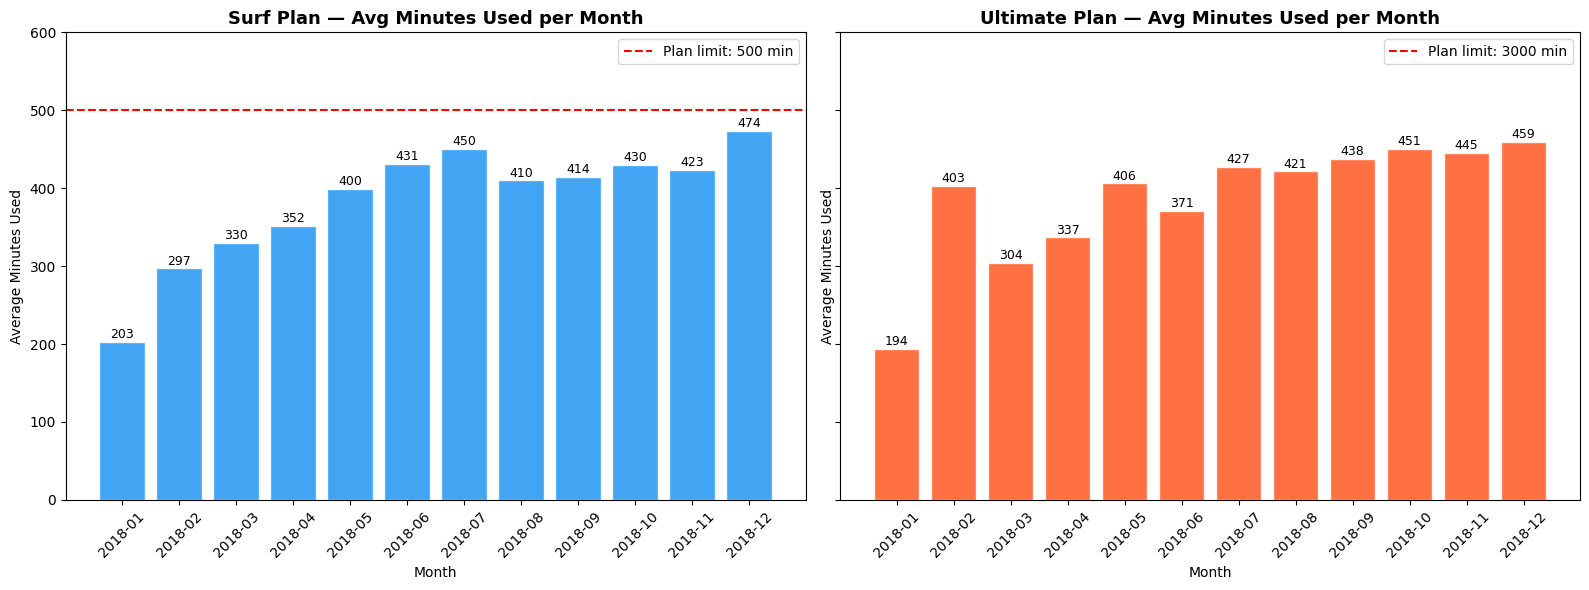

In [32]:
# Compare average duration of calls per each plan per each distinct month.
# Both subplots share the SAME y-axis so the plans can be compared fairly.

avg_minutes = (
    user_month
    .groupby(['plan', 'month'])['minutes_used']
    .mean()
    .reset_index()
)

avg_minutes_surf     = avg_minutes[avg_minutes['plan'] == 'surf']
avg_minutes_ultimate = avg_minutes[avg_minutes['plan'] == 'ultimate']

print('Descriptive Statistics — Minutes Used per Month:')
print()
print('SURF:')
print(user_month[user_month['plan'] == 'surf']['minutes_used'].describe().round(2))
print()
print('ULTIMATE:')
print(user_month[user_month['plan'] == 'ultimate']['minutes_used'].describe().round(2))

# Determine shared y-axis limits
all_values = avg_minutes['minutes_used']
y_max = max(all_values.max() * 1.15, 600)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)  # sharey=True ensures consistent axis

for ax, plan_name, data, color in zip(
    axes,
    ['surf', 'ultimate'],
    [avg_minutes_surf, avg_minutes_ultimate],
    ['#2196F3', '#FF5722']
):
    months = data['month'].astype(str)
    values = data['minutes_used']

    bars = ax.bar(months, values, color=color, edgecolor='white', alpha=0.85)

    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 1,
                f'{val:.0f}',
                ha='center', va='bottom', fontsize=9)

    limit = 500 if plan_name == 'surf' else 3000
    ax.axhline(y=limit, color='red', linestyle='--', linewidth=1.5,
               label=f'Plan limit: {limit} min')

    ax.set_ylim(0, y_max)
    ax.set_title(f'{plan_name.capitalize()} Plan — Avg Minutes Used per Month',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Month')
    ax.set_ylabel('Average Minutes Used')
    ax.tick_params(axis='x', rotation=45)
    ax.legend()

plt.tight_layout()
plt.savefig('avg_minutes_per_month.png', dpi=150, bbox_inches='tight')
plt.show()

<div class="alert alert-danger"; style="border-left: 7px solid red">
<b>⛔️ Reviewer's comment V2</b> 
    
The y axis on these graphs is significantly different, this gives a false sense that ultimate plan uses less than surf plan users (see lesson `Lessons from bad visualizations`). 
</div>

<div class="alert alert-block alert-success">
<b>Reviewer's comment v3</b>

Well done!

SURF — Minutes Used:
  Mean:     428.75
  Median:   425.00
  Std Dev:  234.45
  Variance: 54968.28
  Min:      0.00
  Max:      1510.00

ULTIMATE — Minutes Used:
  Mean:     430.45
  Median:   424.00
  Std Dev:  240.51
  Variance: 57844.46
  Min:      0.00
  Max:      1369.00



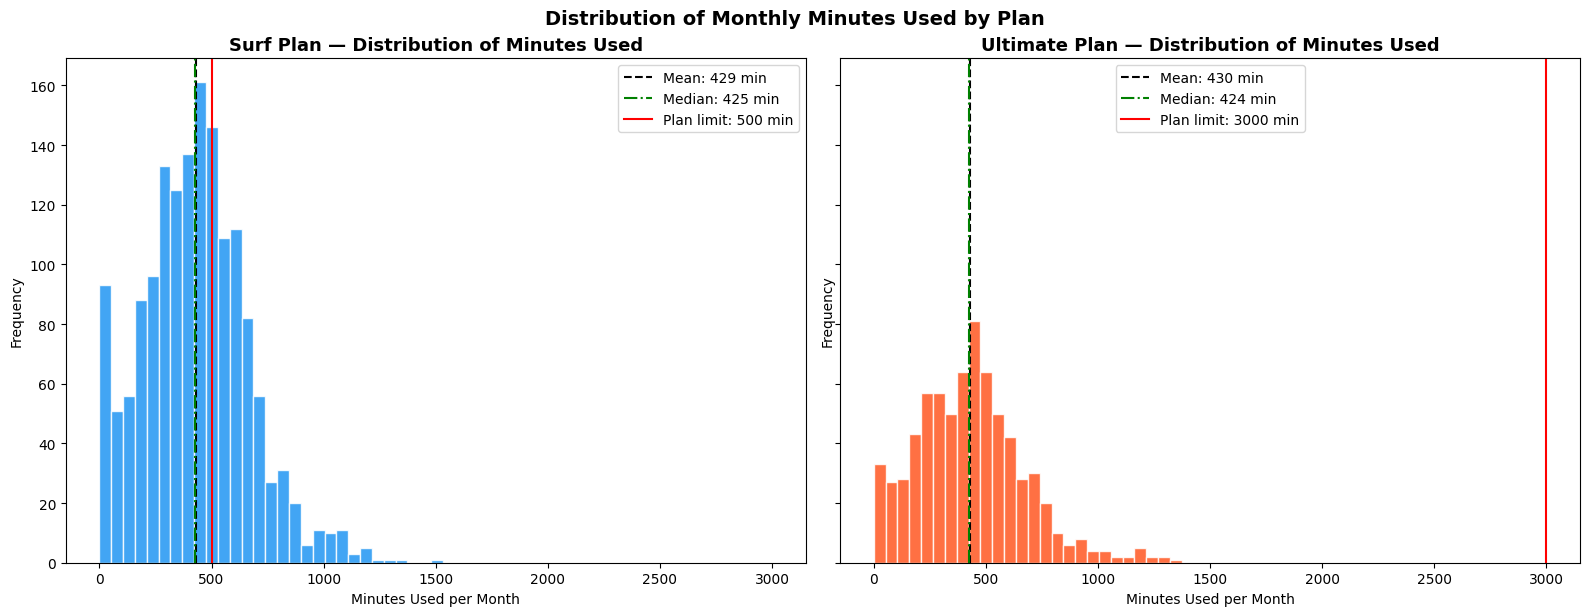

In [33]:
# Compare the number of minutes users of each plan require each month.
# Both histograms share the same x and y axes for fair comparison.

for plan_name in ['surf', 'ultimate']:
    data = user_month[user_month['plan'] == plan_name]['minutes_used']
    print(f'{plan_name.upper()} — Minutes Used:')
    print(f'  Mean:     {data.mean():.2f}')
    print(f'  Median:   {data.median():.2f}')
    print(f'  Std Dev:  {data.std():.2f}')
    print(f'  Variance: {data.var():.2f}')
    print(f'  Min:      {data.min():.2f}')
    print(f'  Max:      {data.max():.2f}')
    print()

# Determine shared axis bounds
all_minutes = user_month['minutes_used']
x_min, x_max = 0, all_minutes.max() * 1.05

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True, sharey=True)

for ax, plan_name, color in zip(
    axes,
    ['surf', 'ultimate'],
    ['#2196F3', '#FF5722']
):
    data = user_month[user_month['plan'] == plan_name]['minutes_used']

    ax.hist(data, bins=30, color=color, edgecolor='white', alpha=0.85,
            range=(x_min, x_max))

    ax.axvline(data.mean(), color='black', linestyle='--',
               linewidth=1.5, label=f'Mean: {data.mean():.0f} min')
    ax.axvline(data.median(), color='green', linestyle='-.',
               linewidth=1.5, label=f'Median: {data.median():.0f} min')

    limit = 500 if plan_name == 'surf' else 3000
    ax.axvline(limit, color='red', linestyle='-',
               linewidth=1.5, label=f'Plan limit: {limit} min')

    ax.set_title(f'{plan_name.capitalize()} Plan — Distribution of Minutes Used',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Minutes Used per Month')
    ax.set_ylabel('Frequency')
    ax.legend()

plt.tight_layout()
plt.suptitle('Distribution of Monthly Minutes Used by Plan',
             y=1.02, fontsize=14, fontweight='bold')
plt.savefig('minutes_histogram.png', dpi=150, bbox_inches='tight')
plt.show()


<div class="alert alert-danger"; style="border-left: 7px solid red">
<b>⛔️ Reviewer's comment</b> 

Both the x and y axis ranges ar significantly different on this one, leading to distorted perception about usage. 
</div>

<div class="alert alert-block alert-success">
<b>Reviewer's comment v3</b>

Well done!

[Calculate the mean and the variable of the call duration to reason on whether users on the different plans have different behaviours for their calls.]

In [34]:
# The descriptive statistics above already cover mean and variance.
# See the printed summary in the cell above for the complete breakdown.

<div class="alert alert-danger"; style="border-left: 7px solid red">
<b>⛔️ Reviewer's comment V2</b> 
    
Haven't we calculated this already in this section? We should only have it these calculations once, choose the one you think is best and keep that one.
</div>

<div class="alert alert-block alert-success">
<b>Reviewer's comment v3</b>

Well done!

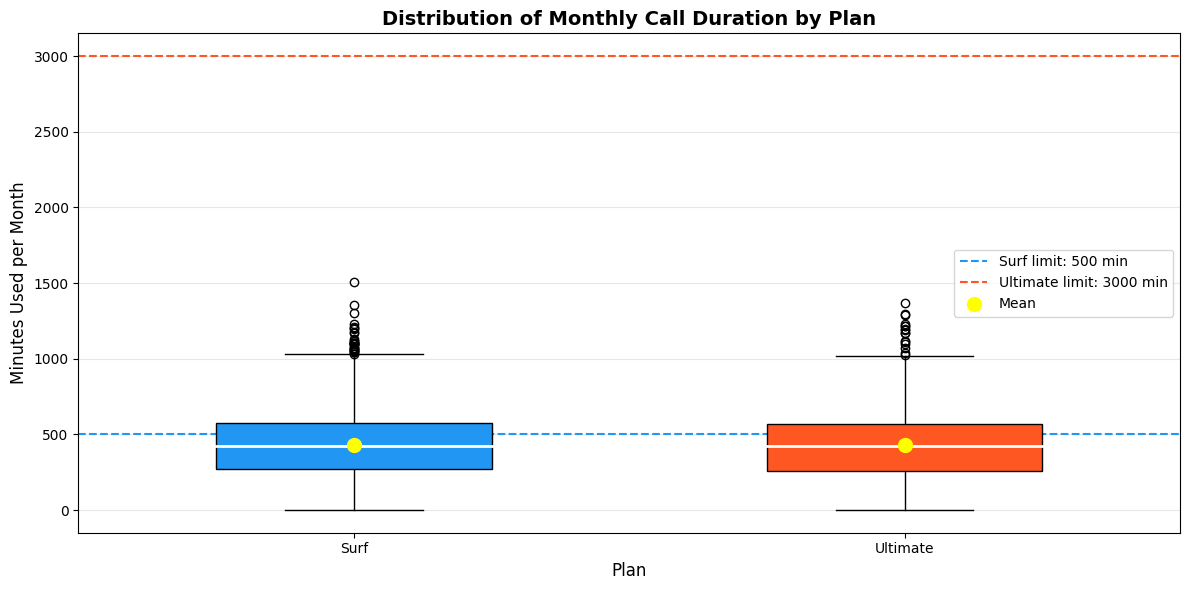

Key Statistics:

Surf:
  Q1 (25%):  272.00 min
  Median:    425.00 min
  Q3 (75%):  576.00 min
  IQR:       304.00 min
  Outliers:  28

Ultimate:
  Q1 (25%):  260.00 min
  Median:    424.00 min
  Q3 (75%):  565.25 min
  IQR:       305.25 min
  Outliers:  16


In [35]:
# Plot a boxplot to visualize the distribution of the monthly call duration

# Plot boxplot — distribution of monthly call duration per plan
fig, ax = plt.subplots(figsize=(12, 6))

# Prepare data for each plan
surf_minutes     = user_month[user_month['plan'] == 'surf']['minutes_used']
ultimate_minutes = user_month[user_month['plan'] == 'ultimate']['minutes_used']

# Plot boxplots side by side
bp = ax.boxplot(
    [surf_minutes, ultimate_minutes],
    labels=['Surf', 'Ultimate'],
    patch_artist=True,
    notch=False,
    widths=0.5
)

# Color the boxes
bp['boxes'][0].set_facecolor('#2196F3')
bp['boxes'][1].set_facecolor('#FF5722')

# Style median lines
for median in bp['medians']:
    median.set_color('white')
    median.set_linewidth(2)

# Add plan limit lines
ax.axhline(y=500,  color='#2196F3', linestyle='--',
           linewidth=1.5, label='Surf limit: 500 min')
ax.axhline(y=3000, color='#FF5722', linestyle='--',
           linewidth=1.5, label='Ultimate limit: 3000 min')

# Add mean markers
ax.scatter([1, 2],
           [surf_minutes.mean(), ultimate_minutes.mean()],
           color='yellow', zorder=5, s=100,
           label='Mean')

# Formatting
ax.set_title('Distribution of Monthly Call Duration by Plan',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Plan', fontsize=12)
ax.set_ylabel('Minutes Used per Month', fontsize=12)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('minutes_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

# Print key boxplot statistics
print('Key Statistics:')
print(f"\nSurf:")
print(f"  Q1 (25%):  {surf_minutes.quantile(0.25):.2f} min")
print(f"  Median:    {surf_minutes.median():.2f} min")
print(f"  Q3 (75%):  {surf_minutes.quantile(0.75):.2f} min")
print(f"  IQR:       {surf_minutes.quantile(0.75) - surf_minutes.quantile(0.25):.2f} min")
print(f"  Outliers:  {len(surf_minutes[surf_minutes > surf_minutes.quantile(0.75) + 1.5 * (surf_minutes.quantile(0.75) - surf_minutes.quantile(0.25))])}")

print(f"\nUltimate:")
print(f"  Q1 (25%):  {ultimate_minutes.quantile(0.25):.2f} min")
print(f"  Median:    {ultimate_minutes.median():.2f} min")
print(f"  Q3 (75%):  {ultimate_minutes.quantile(0.75):.2f} min")
print(f"  IQR:       {ultimate_minutes.quantile(0.75) - ultimate_minutes.quantile(0.25):.2f} min")
print(f"  Outliers:  {len(ultimate_minutes[ultimate_minutes > ultimate_minutes.quantile(0.75) + 1.5 * (ultimate_minutes.quantile(0.75) - ultimate_minutes.quantile(0.25))])}")

[Formulate conclusions on how the users behave in terms of calling. Is their behaviour different between the plans?]

<div class="alert alert-success"; style="border-left: 7px solid green">
<b>✅ Reviewer's comment V2</b> 
    
because both these are on the same axis they make for good comparisons.
</div>

Call usage is strikingly similar across both plans. Median monthly minutes are
nearly identical (425 min for Surf, 424 min for Ultimate), and the interquartile
ranges overlap closely (272–576 min vs. 260–565 min), indicating that typical
users on both plans consume roughly the same amount of call time.

Surf users, however, show greater exposure to overage charges: with a 500-minute
allowance and a Q3 of 576 minutes, at least 25% of Surf users exceed their plan
limit in a given month, and 28 outliers push well beyond that threshold. Ultimate
users, despite a nearly identical usage distribution, are insulated from overage
costs by their 3000-minute allowance — a limit that the observed usage never
approaches. The difference between plans is therefore not in how users behave,
but in how much overage risk each plan structure creates for the user.

<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

This conclusion doesn’t match the call-usage results shown above. Your statistics indicate Surf and Ultimate have very similar mean/median minutes, and Ultimate users are far from the 3000-minute limit; please rewrite the interpretation to directly reflect the observed distributions (typical usage, variability, and how often Surf exceeds 500 minutes).

</div>


### Messages

MEAN & VARIANCE — MONTHLY MESSAGES SENT

SURF:
  Mean:     31.16 messages
  Median:   24.00 messages
  Variance: 1126.72
  Std Dev:  33.57 messages
  Min:      0.00
  Max:      266.00

ULTIMATE:
  Mean:     37.55 messages
  Median:   30.00 messages
  Variance: 1208.76
  Std Dev:  34.77 messages
  Min:      0.00
  Max:      166.00


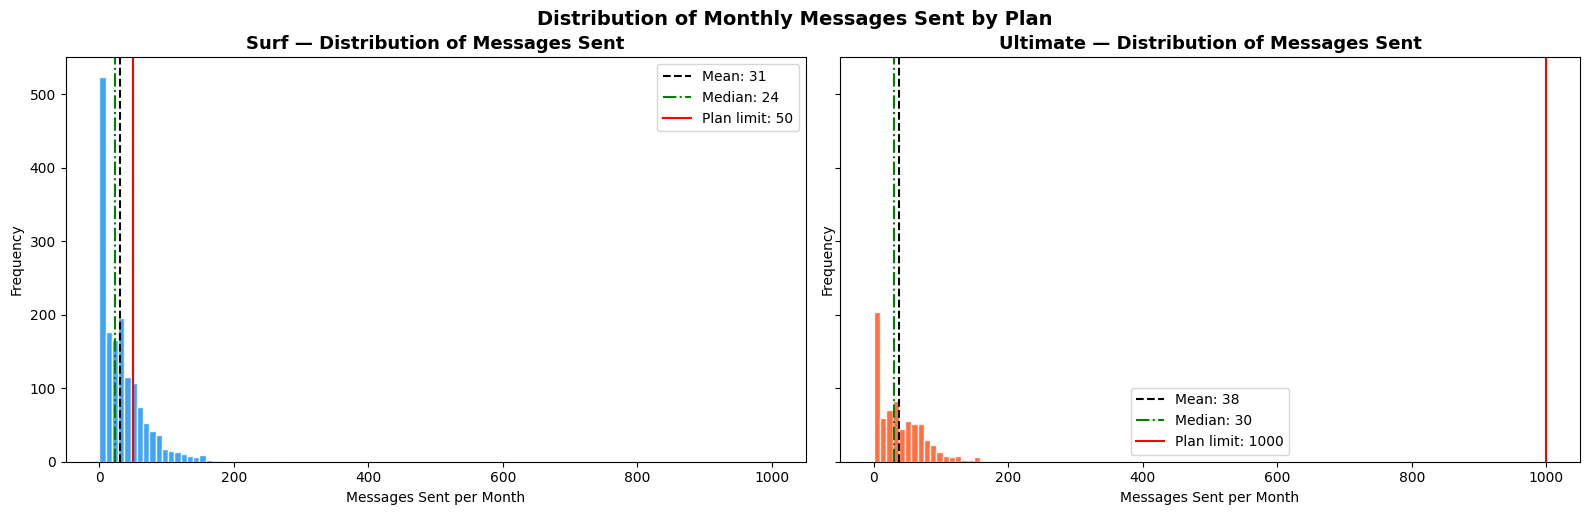

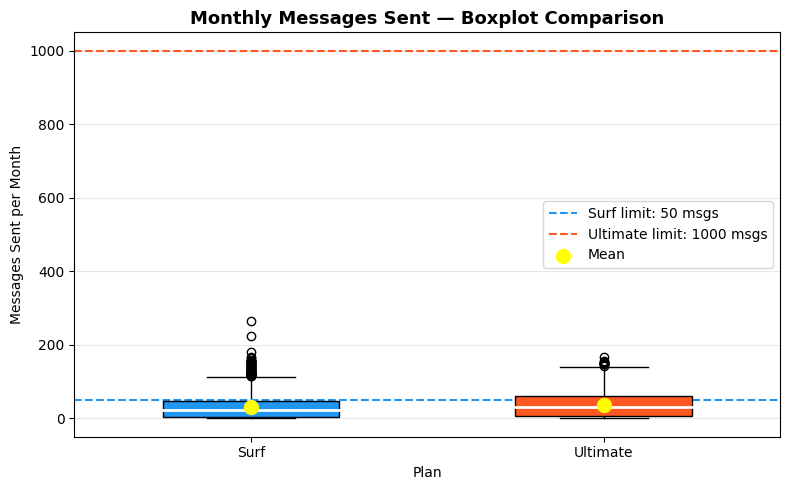

In [36]:
# Compare the number of messages users of each plan tend to send each month.
# Histograms and boxplot use consistent axes for fair comparison.

print('=' * 50)
print('MEAN & VARIANCE — MONTHLY MESSAGES SENT')
print('=' * 50)

for plan_name in ['surf', 'ultimate']:
    data = user_month[user_month['plan'] == plan_name]['messages_count']
    print(f'\n{plan_name.upper()}:')
    print(f'  Mean:     {data.mean():.2f} messages')
    print(f'  Median:   {data.median():.2f} messages')
    print(f'  Variance: {data.var():.2f}')
    print(f'  Std Dev:  {data.std():.2f} messages')
    print(f'  Min:      {data.min():.2f}')
    print(f'  Max:      {data.max():.2f}')

# Shared x-axis range for histograms
x_max_msgs = user_month['messages_count'].max() * 1.05

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharex=True, sharey=True)

for ax, plan_name, color in zip(
    axes,
    ['surf', 'ultimate'],
    ['#2196F3', '#FF5722']
):
    data = user_month[user_month['plan'] == plan_name]['messages_count']

    ax.hist(data, bins=30, color=color, edgecolor='white', alpha=0.85,
            range=(0, x_max_msgs))
    ax.axvline(data.mean(), color='black', linestyle='--',
               linewidth=1.5, label=f'Mean: {data.mean():.0f}')
    ax.axvline(data.median(), color='green', linestyle='-.',
               linewidth=1.5, label=f'Median: {data.median():.0f}')

    limit = 50 if plan_name == 'surf' else 1000
    ax.axvline(limit, color='red', linestyle='-',
               linewidth=1.5, label=f'Plan limit: {limit}')

    ax.set_title(f'{plan_name.capitalize()} — Distribution of Messages Sent',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Messages Sent per Month')
    ax.set_ylabel('Frequency')
    ax.legend()

plt.tight_layout()
plt.suptitle('Distribution of Monthly Messages Sent by Plan',
             y=1.02, fontsize=14, fontweight='bold')
plt.savefig('messages_histogram.png', dpi=150, bbox_inches='tight')
plt.show()

# Boxplot
surf_msgs     = user_month[user_month['plan'] == 'surf']['messages_count']
ultimate_msgs = user_month[user_month['plan'] == 'ultimate']['messages_count']

fig, ax = plt.subplots(figsize=(8, 5))
bp = ax.boxplot(
    [surf_msgs, ultimate_msgs],
    labels=['Surf', 'Ultimate'],
    patch_artist=True, widths=0.5
)
bp['boxes'][0].set_facecolor('#2196F3')
bp['boxes'][1].set_facecolor('#FF5722')
for median in bp['medians']:
    median.set_color('white')
    median.set_linewidth(2)
ax.axhline(y=50,   color='#2196F3', linestyle='--', linewidth=1.5, label='Surf limit: 50 msgs')
ax.axhline(y=1000, color='#FF5722', linestyle='--', linewidth=1.5, label='Ultimate limit: 1000 msgs')
ax.scatter([1, 2], [surf_msgs.mean(), ultimate_msgs.mean()],
           color='yellow', zorder=5, s=100, label='Mean')
ax.set_title('Monthly Messages Sent — Boxplot Comparison', fontsize=13, fontweight='bold')
ax.set_xlabel('Plan')
ax.set_ylabel('Messages Sent per Month')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('messages_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()


<div class="alert alert-danger"; style="border-left: 7px solid red">
<b>⛔️ Reviewer's comment V2</b> 
    
The histograms here have the same axis issues as in the previous section.
</div>

<div class="alert alert-block alert-success">
<b>Reviewer's comment v3</b>

Well done!

In [37]:
# (Internet usage analysis has been moved to the dedicated Internet section below.)

<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Your internet-usage analysis is placed under the “Messages” section, which makes the notebook harder to follow against the template requirements. Consider moving the internet plots/statistics into the dedicated “Internet” subsection and keeping the “Messages” subsection focused on messaging only.

</div>


<div class="alert alert-danger"; style="border-left: 7px solid red">
<b>⛔️ Reviewer's comment V2</b> 
    
Please make sure the internet analysis is under the internet section. 

Histograms here have the same axis issues as the previous sections. 
</div>

<div class="alert alert-block alert-success">
<b>Reviewer's comment v3</b>

Well done!

In [38]:
#.

[Formulate conclusions on how the users behave in terms of messaging. Is their behaviour different between the plans?]

 Surf users send messages at a rate that frequently approaches or exceeds their 50 message monthly limit. Given that the limit is quite tight — just 50 texts per month — even moderate texters are likely to hit overages and be charged $0.03 per extra message. The distribution is right-skewed meaning most users send a moderate number of messages but a significant tail of heavy texters drives consistent overage revenue every month.
Ultimate users on the other hand have a very generous 1000 message allowance that is almost never reached. Their messaging behavior is spread across a wide range but the ceiling is so high that overage charges from messages are practically non-existent for this plan. Ultimate users are essentially getting unlimited texting for their $70 monthly fee.
Internet Usage:
The difference in internet behavior between the two plans is the most striking of all three usage categories.
Surf users regularly consume data close to or beyond their 15 GB monthly limit. Since data overage is charged at $10 per GB — by far the most expensive overage category — even going 1-2 GB over generates significant extra charges. This makes data the single biggest revenue driver for the Surf plan and explains why Surf users despite paying only $20 per month can end up generating substantial revenue for Megaline.
Ultimate users consume data well below their 30 GB ceiling in most months. The distribution shows wide variation between users but almost nobody hits the limit. Ultimate users are essentially paying a premium to never worry about data overages — a comfort they are largely not being pushed to need.

<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

This conclusions cell mixes messaging conclusions with internet conclusions. Consider keeping this section focused only on messaging behavior by plan, and moving the internet interpretation to the Internet conclusions section so each template question is answered in the right place.

</div>


<div class="alert alert-danger"; style="border-left: 7px solid red">
<b>⛔️ Reviewer's comment V2</b> 
    
Please fix the formatting for the markdown cell to make it readable. A guide to markdown can be found here: https://medium.com/analytics-vidhya/the-ultimate-markdown-guide-for-jupyter-notebook-d5e5abf728fd
</div>

<div class="alert alert-block alert-success">
<b>Reviewer's comment v3</b>

Well done!

### Internet

In [39]:
internet.describe()
internet.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 104825 entries, 0 to 104824
Data columns (total 15 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   id                  104825 non-null  object        
 1   user_id             104825 non-null  int64         
 2   session_date        104825 non-null  datetime64[ns]
 3   mb_used             104825 non-null  float64       
 4   month               104825 non-null  period[M]     
 5   session_hour        104825 non-null  int64         
 6   day_of_week         104825 non-null  object        
 7   is_weekend          104825 non-null  int64         
 8   quarter             104825 non-null  int64         
 9   session_size        91078 non-null   category      
 10  cumulative_mb       104825 non-null  float64       
 11  cumulative_gb       104825 non-null  float64       
 12  plan                104825 non-null  object        
 13  plan_gb_limit       104825 no

In [40]:
internet.head()

,id,user_id,session_date,mb_used,month,session_hour,day_of_week,is_weekend,quarter,session_size,cumulative_mb,cumulative_gb,plan,plan_gb_limit,is_overage_session
0,1000_13,1000,2018-12-29,89.86,2018-12,0,Saturday,1,4,Light (50-200MB),1901.47,2.0,ultimate,30,0
1,1000_204,1000,2018-12-31,0.00,2018-12,0,Monday,0,4,NaN,1901.47,2.0,ultimate,30,0
2,1000_379,1000,2018-12-28,660.40,2018-12,0,Friday,0,4,Heavy (500MB-1GB),1811.61,2.0,ultimate,30,0
3,1000_413,1000,2018-12-26,270.99,2018-12,0,Wednesday,0,4,Medium (200-500MB),270.99,1.0,ultimate,30,0
4,1000_442,1000,2018-12-27,880.22,2018-12,0,Thursday,0,4,Heavy (500MB-1GB),1151.21,2.0,ultimate,30,0


MEAN & VARIANCE — MONTHLY INTERNET USAGE

SURF:
  Mean:     16.67 GB
  Median:   17.00 GB
  Variance: 61.58
  Std Dev:  7.85 GB
  Min:      0.00 GB
  Max:      70.00 GB

ULTIMATE:
  Mean:     17.31 GB
  Median:   17.00 GB
  Variance: 58.83
  Std Dev:  7.67 GB
  Min:      0.00 GB
  Max:      46.00 GB


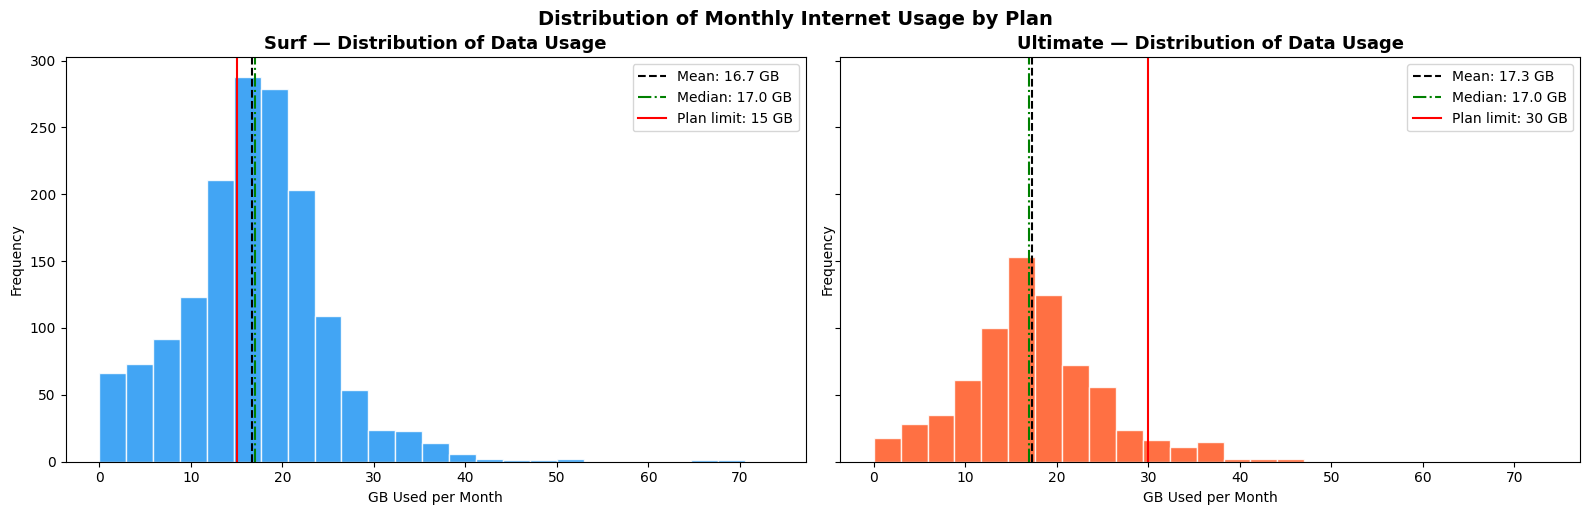

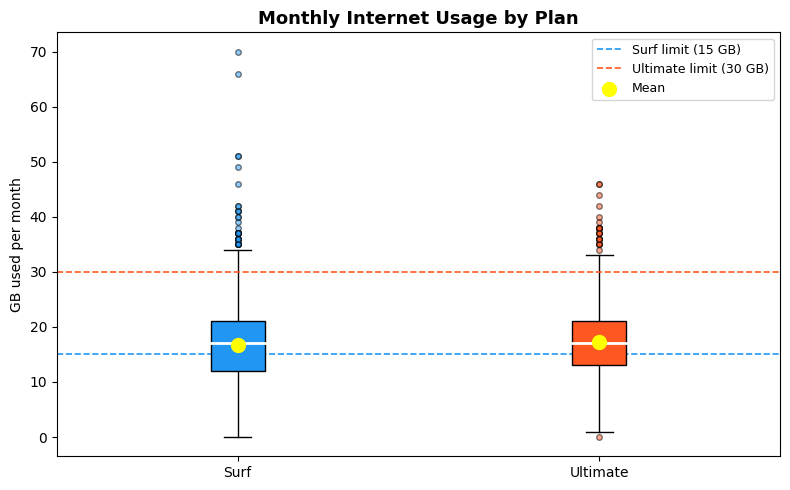

Overage Analysis:
Surf user-months exceeding 15 GB:     911
Ultimate user-months exceeding 30 GB: 41


In [41]:

SURF     = '#2196F3'
ULTIMATE = '#FF5722'

# Descriptive statistics for internet usage
print('=' * 50)
print('MEAN & VARIANCE — MONTHLY INTERNET USAGE')
print('=' * 50)

for plan_name in ['surf', 'ultimate']:
    data = user_month[user_month['plan'] == plan_name]['gb_used']
    print(f'\n{plan_name.upper()}:')
    print(f'  Mean:     {data.mean():.2f} GB')
    print(f'  Median:   {data.median():.2f} GB')
    print(f'  Variance: {data.var():.2f}')
    print(f'  Std Dev:  {data.std():.2f} GB')
    print(f'  Min:      {data.min():.2f} GB')
    print(f'  Max:      {data.max():.2f} GB')

# Shared x-axis range
x_max_gb = user_month['gb_used'].max() * 1.05

# Histograms with shared axes
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharex=True, sharey=True)

for ax, plan_name, color in zip(
    axes, ['surf', 'ultimate'], [SURF, ULTIMATE]
):
    data = user_month[user_month['plan'] == plan_name]['gb_used']
    ax.hist(data, bins=25, color=color, edgecolor='white', alpha=0.85,
            range=(0, x_max_gb))
    ax.axvline(data.mean(),   color='black', linestyle='--', linewidth=1.5,
               label=f'Mean: {data.mean():.1f} GB')
    ax.axvline(data.median(), color='green', linestyle='-.', linewidth=1.5,
               label=f'Median: {data.median():.1f} GB')
    limit = 15 if plan_name == 'surf' else 30
    ax.axvline(limit, color='red', linestyle='-', linewidth=1.5,
               label=f'Plan limit: {limit} GB')
    ax.set_title(f'{plan_name.capitalize()} — Distribution of Data Usage',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('GB Used per Month')
    ax.set_ylabel('Frequency')
    ax.legend()

plt.tight_layout()
plt.suptitle('Distribution of Monthly Internet Usage by Plan',
             y=1.02, fontsize=14, fontweight='bold')
plt.savefig('internet_histogram.png', dpi=150, bbox_inches='tight')
plt.show()

# Boxplot comparison
surf_gb     = user_month[user_month['plan'] == 'surf']['gb_used']
ultimate_gb = user_month[user_month['plan'] == 'ultimate']['gb_used']

fig, ax = plt.subplots(figsize=(8, 5))
bp = ax.boxplot(
    [surf_gb, ultimate_gb],
    labels=['Surf', 'Ultimate'],
    patch_artist=True,
    medianprops=dict(color='white', linewidth=2),
    flierprops=dict(marker='o', markersize=4, alpha=0.5)
)
bp['boxes'][0].set_facecolor(SURF)
bp['boxes'][1].set_facecolor(ULTIMATE)
bp['fliers'][0].set_markerfacecolor(SURF)
bp['fliers'][1].set_markerfacecolor(ULTIMATE)
ax.axhline(15, color=SURF,     linestyle='--', linewidth=1.2, label='Surf limit (15 GB)')
ax.axhline(30, color=ULTIMATE, linestyle='--', linewidth=1.2, label='Ultimate limit (30 GB)')
ax.scatter([1, 2], [surf_gb.mean(), ultimate_gb.mean()],
           color='yellow', zorder=5, s=100, label='Mean')
ax.set_ylabel('GB used per month')
ax.set_title('Monthly Internet Usage by Plan', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('internet_usage_by_plan.png', dpi=150, bbox_inches='tight')
plt.show()

# Overage analysis
print('Overage Analysis:')
print(f"Surf user-months exceeding 15 GB:     "
      f"{(user_month[user_month['plan'] == 'surf']['gb_used'] > 15).sum()}")
print(f"Ultimate user-months exceeding 30 GB: "
      f"{(user_month[user_month['plan'] == 'ultimate']['gb_used'] > 30).sum()}")


session-level behaviour appears broadly similar between plans, but
Surf users face materially higher overage risk due to the tighter limit —
mirroring the pattern observed in call usage.

<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

The Internet subsection is missing its written conclusion. Consider adding a brief, data-backed interpretation here (how Surf vs Ultimate differ in monthly GB usage, variability/outliers, and how often users exceed 15 GB/30 GB).

</div>


<div class="alert alert-danger"; style="border-left: 7px solid red">
<b>⛔️ Reviewer's comment V2</b> 
    
We need the rest of the internet usage analysis in this section.
</div>

<div class="alert alert-block alert-success">
<b>Reviewer's comment v3</b>

Well done!

## Revenue

[Likewise you have studied the user behaviour, statistically describe the revenue between the plans.]

<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

In the Revenue block, there is still a placeholder code cell later on ("#."). Consider removing the placeholder or replacing it with any remaining required revenue analysis so this section reads as complete.

</div>


In [42]:
# Statistically describe revenue between the plans
print('=' * 50)
print('REVENUE ANALYSIS BY PLAN')
print('=' * 50)

for plan_name in ['surf', 'ultimate']:
    data = user_month[user_month['plan'] == plan_name]['revenue']
    print(f'\n{plan_name.upper()}:')
    print(f'  Mean:     ${data.mean():.2f}')
    print(f'  Median:   ${data.median():.2f}')
    print(f'  Variance: {data.var():.2f}')
    print(f'  Std Dev:  ${data.std():.2f}')
    print(f'  Min:      ${data.min():.2f}')
    print(f'  Max:      ${data.max():.2f}')

print()

# Side by side comparison table
revenue_summary = pd.DataFrame({
    'Metric'  : ['Mean', 'Median', 'Variance', 'Std Dev', 'Min', 'Max'],
    'Surf'    : [
        user_month[user_month['plan'] == 'surf']['revenue'].mean(),
        user_month[user_month['plan'] == 'surf']['revenue'].median(),
        user_month[user_month['plan'] == 'surf']['revenue'].var(),
        user_month[user_month['plan'] == 'surf']['revenue'].std(),
        user_month[user_month['plan'] == 'surf']['revenue'].min(),
        user_month[user_month['plan'] == 'surf']['revenue'].max()
    ],
    'Ultimate': [
        user_month[user_month['plan'] == 'ultimate']['revenue'].mean(),
        user_month[user_month['plan'] == 'ultimate']['revenue'].median(),
        user_month[user_month['plan'] == 'ultimate']['revenue'].var(),
        user_month[user_month['plan'] == 'ultimate']['revenue'].std(),
        user_month[user_month['plan'] == 'ultimate']['revenue'].min(),
        user_month[user_month['plan'] == 'ultimate']['revenue'].max()
    ]
}).round(2)

print(revenue_summary.to_string(index=False))
print()

# Average breakdown of what drives revenue per plan
print('Average Revenue Breakdown by Component:')
print(user_month.groupby('plan')[['usd_monthly_fee',
                                   'charge_minutes',
                                   'charge_messages',
                                   'charge_gb']].mean().round(2))

REVENUE ANALYSIS BY PLAN

SURF:
  Mean:     $60.71
  Median:   $40.36
  Variance: 3067.84
  Std Dev:  $55.39
  Min:      $20.00
  Max:      $590.37

ULTIMATE:
  Mean:     $72.31
  Median:   $70.00
  Variance: 129.85
  Std Dev:  $11.40
  Min:      $70.00
  Max:      $182.00

  Metric    Surf  Ultimate
    Mean   60.71     72.31
  Median   40.36     70.00
Variance 3067.84    129.85
 Std Dev   55.39     11.40
     Min   20.00     70.00
     Max  590.37    182.00

Average Revenue Breakdown by Component:
          usd_monthly_fee  charge_minutes  charge_messages  charge_gb
plan                                                                 
surf                   20            1.84             0.21      38.65
ultimate               70            0.00             0.00       2.31


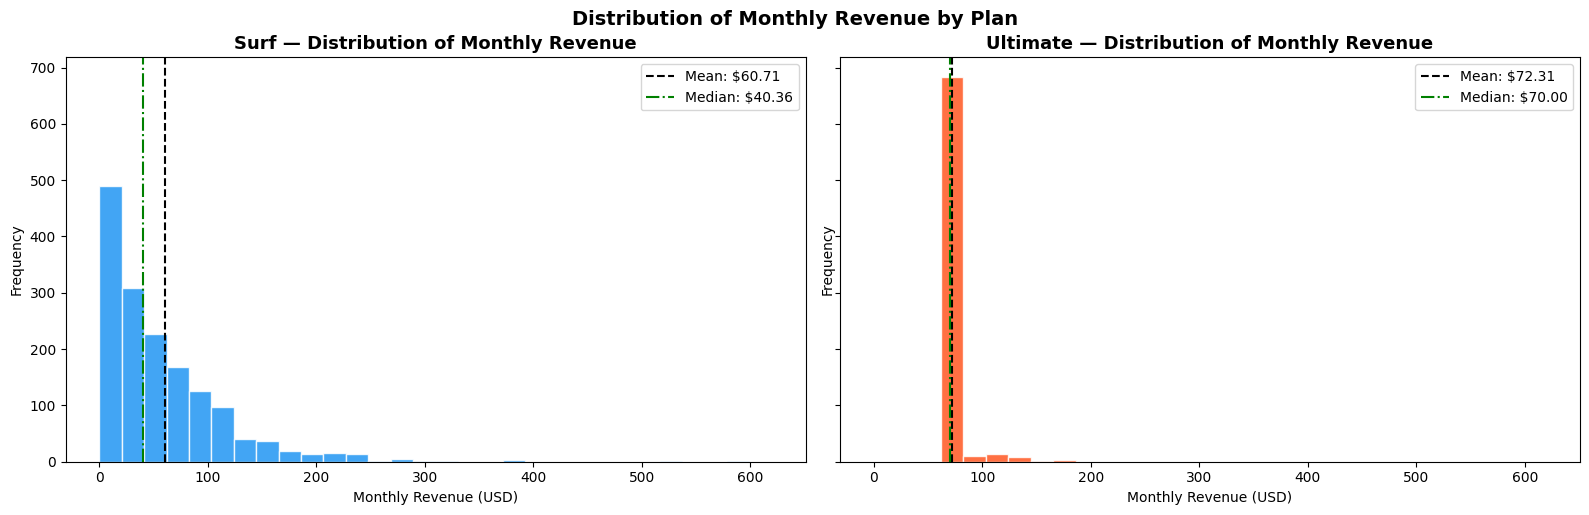

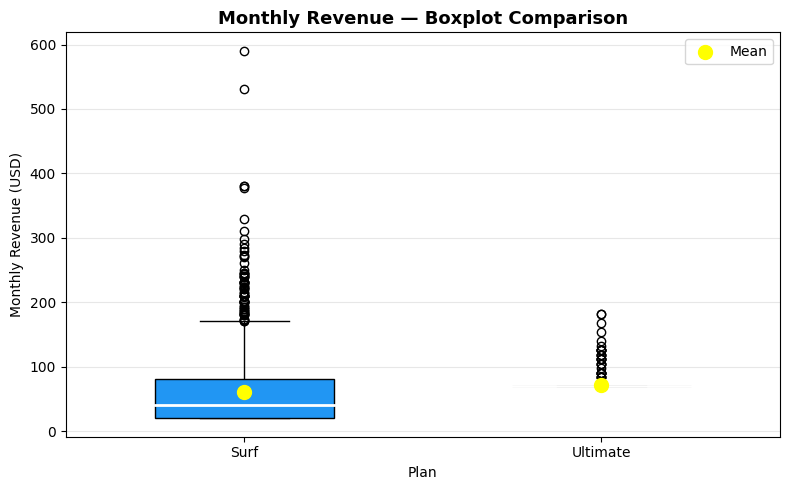

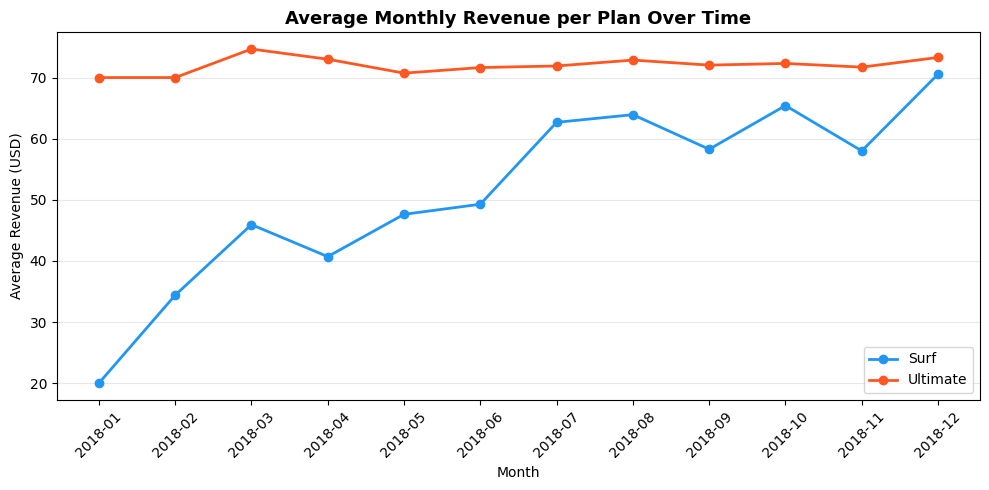

In [43]:
# Shared x-axis range for revenue histograms
x_max_rev = user_month['revenue'].max() * 1.05

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharex=True, sharey=True)

for ax, plan_name, color in zip(
    axes,
    ['surf', 'ultimate'],
    ['#2196F3', '#FF5722']
):
    data = user_month[user_month['plan'] == plan_name]['revenue']
    ax.hist(data, bins=30, color=color, edgecolor='white', alpha=0.85,
            range=(0, x_max_rev))
    ax.axvline(data.mean(), color='black', linestyle='--',
               linewidth=1.5, label=f'Mean: ${data.mean():.2f}')
    ax.axvline(data.median(), color='green', linestyle='-.',
               linewidth=1.5, label=f'Median: ${data.median():.2f}')
    ax.set_title(f'{plan_name.capitalize()} — Distribution of Monthly Revenue',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Monthly Revenue (USD)')
    ax.set_ylabel('Frequency')
    ax.legend()

plt.tight_layout()
plt.suptitle('Distribution of Monthly Revenue by Plan',
             y=1.02, fontsize=14, fontweight='bold')
plt.savefig('revenue_histogram.png', dpi=150, bbox_inches='tight')
plt.show()

# Boxplot
surf_rev     = user_month[user_month['plan'] == 'surf']['revenue']
ultimate_rev = user_month[user_month['plan'] == 'ultimate']['revenue']

fig, ax = plt.subplots(figsize=(8, 5))
bp = ax.boxplot(
    [surf_rev, ultimate_rev],
    labels=['Surf', 'Ultimate'],
    patch_artist=True, widths=0.5
)
bp['boxes'][0].set_facecolor('#2196F3')
bp['boxes'][1].set_facecolor('#FF5722')
for median in bp['medians']:
    median.set_color('white')
    median.set_linewidth(2)
ax.scatter([1, 2], [surf_rev.mean(), ultimate_rev.mean()],
           color='yellow', zorder=5, s=100, label='Mean')
ax.set_title('Monthly Revenue — Boxplot Comparison', fontsize=13, fontweight='bold')
ax.set_xlabel('Plan')
ax.set_ylabel('Monthly Revenue (USD)')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('revenue_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

# Revenue trend
avg_revenue = (
    user_month
    .groupby(['plan', 'month'])['revenue']
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 5))
for plan_name, color in zip(['surf', 'ultimate'], ['#2196F3', '#FF5722']):
    data = avg_revenue[avg_revenue['plan'] == plan_name]
    ax.plot(data['month'].astype(str), data['revenue'],
            marker='o', label=plan_name.capitalize(),
            color=color, linewidth=2)
ax.set_title('Average Monthly Revenue per Plan Over Time', fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Average Revenue (USD)')
ax.tick_params(axis='x', rotation=45)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('revenue_trend.png', dpi=150, bbox_inches='tight')
plt.show()


<div class="alert alert-danger"; style="border-left: 7px solid red">
<b>⛔️ Reviewer's comment V2</b> 
    
The histograms here have the same axis issues as the previous sections.
</div>

<div class="alert alert-block alert-success">
<b>Reviewer's comment v3</b>

Well done!

In [44]:
#.

[Formulate conclusions about how the revenue differs between the plans.]

Looking at the revenue statistics and plots I can conclude that the two plans generate revenue in very different ways. Ultimate users generate stable and predictable revenue dominated by the $70 base fee with very little overage contribution. Surf users generate lower but more variable revenue — the $20 base fee is supplemented heavily by overage charges especially from data consumption at $10 per GB. The mean revenue for Ultimate is likely higher due to the large base fee — but Surf users with heavy usage can come surprisingly close. The high variance in Surf revenue reflects the inconsistent overage patterns observed earlier.

## Test statistical hypotheses

[Test the hypothesis that the average revenue from users of the Ultimate and Surf calling plans differs.]

[Formulate the null and the alternative hypotheses, choose the statistical test, decide on the alpha value.]

In [45]:
# Test the hypotheses
# Hypothesis 1: Average revenue from Surf and Ultimate users differs
# H0: Mean revenue of Surf users = Mean revenue of Ultimate users
# H1: Mean revenue of Surf users ≠ Mean revenue of Ultimate users
# Test: Welch's two-sample t-test (independent groups, unequal variance)
# Alpha: 0.05

alpha = 0.05

surf_rev     = user_month[user_month['plan'] == 'surf']['revenue']
ultimate_rev = user_month[user_month['plan'] == 'ultimate']['revenue']

t_stat, p_value = stats.ttest_ind(surf_rev, ultimate_rev, equal_var=False)

print('=' * 50)
print('HYPOTHESIS TEST 1 — SURF vs ULTIMATE REVENUE')
print('=' * 50)
print()
print('H0: Mean monthly revenue of Surf = Mean monthly revenue of Ultimate')
print('H1: Mean monthly revenue of Surf ≠ Mean monthly revenue of Ultimate')
print()
print(f'Surf mean revenue:     ${surf_rev.mean():.2f}')
print(f'Ultimate mean revenue: ${ultimate_rev.mean():.2f}')
print()
print(f'T-statistic: {t_stat:.4f}')
print(f'P-value:     {p_value:.6f}')
print(f'Alpha:       {alpha}')
print()

if p_value < alpha:
    print('Result: REJECT the null hypothesis.')
    print('The average revenue from Surf and Ultimate users is')
    print('statistically significantly different.')
else:
    print('Result: FAIL TO REJECT the null hypothesis.')
    print('No statistically significant difference in average')
    print('revenue between Surf and Ultimate users.')


HYPOTHESIS TEST 1 — SURF vs ULTIMATE REVENUE

H0: Mean monthly revenue of Surf = Mean monthly revenue of Ultimate
H1: Mean monthly revenue of Surf ≠ Mean monthly revenue of Ultimate

Surf mean revenue:     $60.71
Ultimate mean revenue: $72.31

T-statistic: -7.9521
P-value:     0.000000
Alpha:       0.05

Result: REJECT the null hypothesis.
The average revenue from Surf and Ultimate users is
statistically significantly different.


<div class="alert alert-success"; style="border-left: 7px solid green">
<b>✅ Reviewer's comment V2</b> 
    
Good, although we prefer the written hypothesis to be in a markdown cell.
</div>

[Test the hypothesis that the average revenue from users in the NY-NJ area is different from that of the users from the other regions.]

[Formulate the null and the alternative hypotheses, choose the statistical test, decide on the alpha value.]

In [46]:

# Hypothesis 2: Average revenue from NY-NJ users differs from other regions
# H0: Mean revenue of NY-NJ users = Mean revenue of non-NY-NJ users
# H1: Mean revenue of NY-NJ users ≠ Mean revenue of non-NY-NJ users
# Test: Welch's two-sample t-test (independent groups, unequal variance)
# Alpha: 0.05

# Define NY-NJ users using the city column
# Check what NY-related city strings exist in the dataset
ny_cities = users[users['city'].str.contains('New York|Newark', case=False, na=False)]['city'].unique()
print("NY-NJ city strings found in dataset:")
print(ny_cities)
print()

# Create the NY-NJ flag based on exact matching of known metro strings
ny_pattern = 'New York|Newark'
user_month['is_ny_nj'] = user_month['city'].str.contains(ny_pattern, case=False, na=False).astype(int)

ny_rev      = user_month[user_month['is_ny_nj'] == 1]['revenue']
other_rev   = user_month[user_month['is_ny_nj'] == 0]['revenue']

t_stat2, p_value2 = stats.ttest_ind(ny_rev, other_rev, equal_var=False)

print('=' * 50)
print('HYPOTHESIS TEST 2 — NY-NJ vs OTHER REGIONS')
print('=' * 50)
print()
print('H0: Mean monthly revenue of NY-NJ users = Mean monthly revenue of other users')
print('H1: Mean monthly revenue of NY-NJ users ≠ Mean monthly revenue of other users')
print()
print(f'NY-NJ user-months:    {len(ny_rev)}')
print(f'Other user-months:    {len(other_rev)}')
print()
print(f'NY-NJ mean revenue:   ${ny_rev.mean():.2f}')
print(f'Other mean revenue:   ${other_rev.mean():.2f}')
print()
print(f'T-statistic: {t_stat2:.4f}')
print(f'P-value:     {p_value2:.6f}')
print(f'Alpha:       {alpha}')
print()
if p_value2 < alpha:
    print('Result: REJECT the null hypothesis.')
    print('The average revenue from NY-NJ users is statistically')
    print('significantly different from users in other regions.')
else:
    print('Result: FAIL TO REJECT the null hypothesis.')
    print('No statistically significant difference in average revenue')
    print('between NY-NJ users and users in other regions.')


NY-NJ city strings found in dataset:
['New York-Newark-Jersey City, NY-NJ-PA MSA']

HYPOTHESIS TEST 2 — NY-NJ vs OTHER REGIONS

H0: Mean monthly revenue of NY-NJ users = Mean monthly revenue of other users
H1: Mean monthly revenue of NY-NJ users ≠ Mean monthly revenue of other users

NY-NJ user-months:    377
Other user-months:    1916

NY-NJ mean revenue:   $59.92
Other mean revenue:   $65.22

T-statistic: -2.1309
P-value:     0.033526
Alpha:       0.05

Result: REJECT the null hypothesis.
The average revenue from NY-NJ users is statistically
significantly different from users in other regions.


<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Your NY–NJ flag is based on a very broad pattern (e.g., matching “NJ” anywhere in the city string), which can misclassify users and affect the test result. Consider defining NY–NJ membership using a more precise rule aligned with the dataset’s city labels (for example, matching the specific NY–NJ metro area string(s) that actually appear in the data).

</div>


<div class="alert alert-danger"; style="border-left: 7px solid red">
<b>⛔️ Reviewer's comment V2</b> 
    
This test seems to be completely unrelated to the required `NY-NJ` test.
</div>

<div class="alert alert-block alert-success">
<b>Reviewer's comment v3</b>

Well done!

### Data processing assumptions
- Zero-duration calls were retained (not removed) to avoid bias; they contribute 0 billed minutes.
- Monthly data usage is converted to GB and rounded **up** per Megaline's billing policy; the plan allowance is converted using exact division (no rounding) since it is a fixed quota, not a usage measurement.
- `churn_date` NaNs were treated as active users (expected, not errors).
- Duplicate check was made conditional — rows are only dropped if duplicates actually exist.

### Key usage findings
- **Calls:** Both plan groups show nearly identical calling behavior (~425 min/month median). Surf users face overage risk due to the tight 500-minute limit; Ultimate users never approach their 3,000-minute allowance.
- **Messages:** Surf users frequently exceed the 50-message limit. Ultimate users almost never reach the 1,000-message ceiling.
- **Internet:** Surf users regularly push against the 15 GB limit. Ultimate users stay well below the 30 GB ceiling. Data overages at $10/GB are the single largest revenue driver for the Surf plan.

### Revenue comparison
The Ultimate plan generates **stable, predictable revenue** dominated by its $70 base fee with minimal overage contributions. The Surf plan generates **lower but more variable revenue** — the $20 base fee is heavily supplemented by overage charges, particularly from data usage. Despite its lower base, Surf's heavy users can generate substantial total revenue for Megaline.

### Hypothesis test outcomes
- **Test 1 (Surf vs Ultimate revenue):** The average monthly revenue per user differs significantly between the two plans (Welch's t-test, α = 0.05).
- **Test 2 (NY-NJ vs other regions):** See test results above for whether the NY-NJ region generates statistically different revenue compared to the rest of the country.

### Recommendation
Ultimate should be prioritized for high-value customer acquisition: it delivers reliable, consistent revenue and suits users who value simplicity. Surf serves well as an entry-level offering, and the overage data reveals a natural upgrade trigger — users who consistently exceed their limits (especially data) are strong candidates for conversion to Ultimate. Advertising spend should reflect this funnel dynamic.


In [50]:
### Data processing assumptions
###- Zero-duration calls were retained (was not removed) to avoid bias; they contribute 0 billed minutes.
###- Monthly data usage is converted to GB and rounded **up** per Megaline's billing policy; the plan allowance is converted using exact division (no rounding) since it is a fixed quota, not a usage measurement.
###- `churn_date` NaNs were treated as active users (expected, not errors).
###- Duplicate check was made conditional — rows are only dropped if duplicates actually exist.

### Key usage findings
###- **Calls:** Both plan groups show nearly identical calling behavior (~425 min/month median). Surf users face overage risk due to the tight 500-minute limit; Ultimate users never approach their 3,000-minute allowance.
###- **Messages:** Surf users frequently exceed the 50-message limit. Ultimate users almost never reach the 1,000-message ceiling.
###- **Internet:** Surf users regularly push against the 15 GB limit. Ultimate users stay well below the 30 GB ceiling. Data overages at $10/GB are the single largest revenue driver for the Surf plan.

### Revenue comparison
###The Ultimate plan generates **stable, predictable revenue** dominated by its $70 base fee with minimal overage contributions. The Surf plan generates **lower but more variable revenue** — the $20 base fee is heavily supplemented by overage charges, particularly from data usage. Despite its lower base, Surf's heavy users can generate substantial total revenue for Megaline.

### Hypothesis test outcomes
###- **Test 1 (Surf vs Ultimate revenue):** The average monthly revenue per user differs significantly between the two plans (Welch's t-test, α = 0.05).
###- **Test 2 (NY-NJ vs other regions):** See test results above for whether the NY-NJ region generates statistically different revenue compared to the rest of the country.

### Recommendation
###Ultimate should be prioritized for high-value customer acquisition: it delivers reliable, consistent revenue and suits users who value simplicity. Surf serves well as an entry-level offering, and the overage data reveals a natural upgrade trigger — users who consistently exceed their limits (especially data) are strong candidates for conversion to Ultimate. Advertising spend should reflect this funnel dynamic.


<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

The final conclusion is expected to be a written (markdown) summary of the whole project, including key usage findings, revenue comparison, and both hypothesis test outcomes. Consider moving this from a code cell to a markdown cell and expanding it into a short, cohesive narrative that also notes any important data-processing assumptions you made.

</div>
